# Demo 3 — TD learning: an actor–critic reaches in 8 directions

**Tutorial:** *Synaptic Plasticity and Learning* (CCNSS2026) · Lecture 2

**The third factor, again.** In Demo 1 plasticity was 2-factor (Hebb/Oja: pre × post). In
Demo 2 a *global scalar* (the EGHR error gate) turned it into a learning rule. Reinforcement
learning gives that scalar its most famous biological identity: the **reward-prediction error**

$$\delta_t \;=\; r_t + \gamma\,V(s_{t+1}) - V(s_t),$$

the **temporal-difference (TD) error** — believed to be broadcast by midbrain **dopamine** and to
gate synaptic plasticity (a *three-factor* rule: eligibility trace × $\delta$). Here a small
**actor–critic** network learns a **center-out reaching task**: the critic learns the value
$V(s)$, the actor learns the policy $\pi(a\mid s)$, and **both are updated by the same scalar
$\delta$.** Afterwards we look inside the network and find **directional (cosine) tuning** and a
**Georgopoulos population vector** — the very analyses applied to monkey motor cortex (M1) in
the *Neural Data Analysis* tutorial.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110


## The environment — center-out reaching

Eight targets sit on a ring. Each trial cues one target; the agent starts at the center and
picks one of 8 step-directions. It earns $+1$ for reaching the cued target and a small cost per
step. We add **potential-based shaping** $F=\gamma\Phi(s')-\Phi(s)$ with $\Phi(s)=-\lVert\text{pos}-\text{target}\rVert$,
which speeds learning *without changing the optimal policy*.


In [2]:
N_TARGETS = 8
ANGLES  = np.arange(N_TARGETS) * 2*np.pi / N_TARGETS
TARGETS = np.stack([np.cos(ANGLES), np.sin(ANGLES)], 1)   # targets on unit circle
ACT_DIRS = TARGETS.copy()                                  # 8 movement directions
STEP, REACH_R, MAX_STEPS = 0.18, 0.18, 40

def features(pos, tid):
    tgt = TARGETS[tid]
    return np.concatenate([pos, tgt, tgt - pos])           # [pos, target, vector-to-target]

def env_step(pos, tid, a):
    pos = np.clip(pos + STEP * ACT_DIRS[a], -1.6, 1.6)
    dist = np.linalg.norm(pos - TARGETS[tid])
    done = dist < REACH_R
    return pos, (1.0 if done else -0.02), done

def potential(pos, tid):
    return -np.linalg.norm(pos - TARGETS[tid])


## The actor–critic network

One hidden layer of $\tanh$ units — these are our *model neurons*. They feed two heads: the
**critic** $V(s)=\mathbf w_v^\top\mathbf h$ and the **actor** (softmax policy over 8 actions). The
**TD error $\delta$ multiplies every weight update** — the single global "third factor."


In [3]:
N_IN, N_HID = 6, 64
gamma = 0.97
lr_actor, lr_critic, lr_hid = 5e-3, 1e-2, 5e-3
SHAPE, ENT = 0.5, 1e-2

Wh = rng.standard_normal((N_HID, N_IN)) * np.sqrt(1.0/N_IN); bh = np.zeros(N_HID)
Wv = np.zeros(N_HID); bv = 0.0                              # critic head
Wa = rng.standard_normal((N_TARGETS, N_HID)) * 0.01; ba = np.zeros(N_TARGETS)  # actor head

def forward(phi):
    h = np.tanh(Wh @ phi + bh)
    v = Wv @ h + bv
    logits = Wa @ h + ba; logits -= logits.max()
    p = np.exp(logits); p /= p.sum()
    return h, v, p


In [4]:
def train(n_ep=6000):
    global Wh, bh, Wv, bv, Wa, ba
    succ, ret = [], []
    for ep in range(n_ep):
        tid = ep % N_TARGETS                 # cycle through the 8 targets
        pos = np.zeros(2); done = False; t = 0; G = 0.0; reached = 0
        while not done and t < MAX_STEPS:
            phi = features(pos, tid)
            h, v, p = forward(phi)
            a = rng.choice(N_TARGETS, p=p)               # sample action from policy
            pos2, r, done = env_step(pos, tid, a)
            r_s = r + SHAPE * ((0.0 if done else gamma*potential(pos2, tid)) - potential(pos, tid))
            _, v2, _ = forward(features(pos2, tid))
            delta = r_s + (0.0 if done else gamma * v2) - v     # <-- TD error (third factor)

            # critic head:  w_v += lr * delta * h
            Wv += lr_critic * delta * h; bv += lr_critic * delta
            # actor head:   policy gradient scaled by delta (+ small entropy bonus)
            dlog = -p.copy(); dlog[a] += 1.0
            dent = -p * (np.log(p + 1e-9) + 1.0)
            g_act = delta * dlog + ENT * dent
            Wa += lr_actor * np.outer(g_act, h); ba += lr_actor * g_act
            # shared hidden layer: gradient from both heads, all gated by delta
            dh = delta * Wv + Wa.T @ g_act
            dpre = dh * (1 - h**2)
            Wh += lr_hid * np.outer(dpre, phi); bh += lr_hid * dpre

            pos = pos2; t += 1; G += r
            if done: reached = 1
        succ.append(reached); ret.append(G)
    return np.array(succ), np.array(ret)

succ, ret = train()
print("success rate (last 800 episodes):", round(succ[-800:].mean(), 3))


success rate (last 800 episodes): 1.0


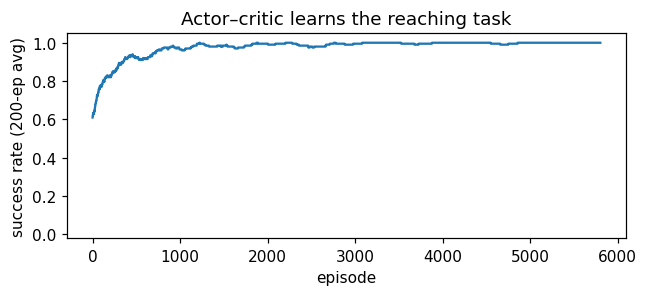

In [5]:
# learning curve (smoothed success rate)
def smooth(x, k=200): return np.convolve(x, np.ones(k)/k, mode="valid")
plt.figure(figsize=(6, 2.8))
plt.plot(smooth(succ))
plt.xlabel("episode"); plt.ylabel("success rate (200-ep avg)")
plt.title("Actor–critic learns the reaching task"); plt.ylim(-0.02, 1.05)
plt.tight_layout(); plt.show()


## What the agent learned — trajectories and value\nGreedy rollouts to all 8 targets, and the critic's value landscape $V(s)$ for one target.

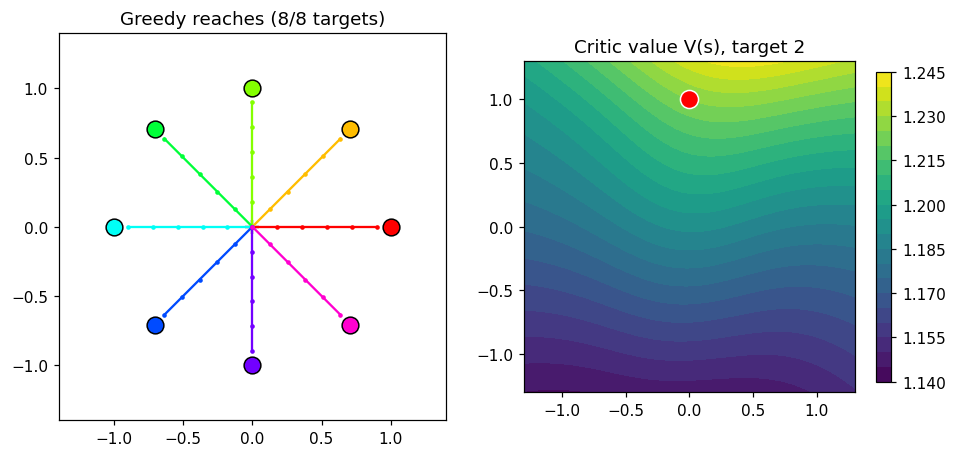

greedy reached: 8 / 8


In [6]:
def rollout(tid):
    pos = np.zeros(2); traj = [pos.copy()]
    for _ in range(MAX_STEPS):
        _, _, p = forward(features(pos, tid))
        pos, r, done = env_step(pos, tid, int(np.argmax(p))); traj.append(pos.copy())
        if done: break
    return done, np.array(traj)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
cols = plt.cm.hsv(np.linspace(0, 1, N_TARGETS, endpoint=False))
n_ok = 0
for tid in range(N_TARGETS):
    ok, tr = rollout(tid); n_ok += ok
    ax[0].plot(tr[:, 0], tr[:, 1], "-o", ms=2, color=cols[tid])
    ax[0].scatter(*TARGETS[tid], s=120, color=cols[tid], edgecolor="k", zorder=3)
ax[0].scatter(0, 0, c="k", marker="+", s=80); ax[0].set_aspect("equal")
ax[0].set_title(f"Greedy reaches ({n_ok}/8 targets)"); ax[0].set_xlim(-1.4, 1.4); ax[0].set_ylim(-1.4, 1.4)

tid = 2
gx = np.linspace(-1.3, 1.3, 60); X, Y = np.meshgrid(gx, gx)
V = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        _, V[i, j], _ = forward(features(np.array([X[i, j], Y[i, j]]), tid))
im = ax[1].contourf(X, Y, V, 20, cmap="viridis")
ax[1].scatter(*TARGETS[tid], s=140, color="r", edgecolor="w"); ax[1].set_aspect("equal")
ax[1].set_title(f"Critic value V(s), target {tid}"); plt.colorbar(im, ax=ax[1], shrink=0.8)
plt.tight_layout(); plt.show()
print("greedy reached:", n_ok, "/ 8")


## Looking inside: M1-style directional tuning

For each hidden unit we measure its mean activity across the eight reach directions and fit a
**cosine tuning curve** $a(\theta)=b+m\cos(\theta-\theta_{\text{PD}})$ — exactly the form
Georgopoulos found for M1 neurons. $\theta_{\text{PD}}$ is the unit's **preferred direction**.


In [7]:
# mean hidden activity per reach direction (analogue of trial-averaged M1 firing rates)
H = np.zeros((N_TARGETS, N_HID))
for tid in range(N_TARGETS):
    pos = np.zeros(2); acts = []
    for _ in range(MAX_STEPS):
        h, _, p = forward(features(pos, tid)); acts.append(h)
        pos, r, done = env_step(pos, tid, int(np.argmax(p)))
        if done: break
    H[tid] = np.mean(acts, 0)

# fit a + b cos + c sin  ->  preferred direction & tuning quality
Xd = np.stack([np.ones(N_TARGETS), np.cos(ANGLES), np.sin(ANGLES)], 1)
PDs, depths, r2s = [], [], []
for i in range(N_HID):
    beta, *_ = np.linalg.lstsq(Xd, H[:, i], rcond=None)
    pred = Xd @ beta
    r2 = 1 - np.sum((H[:, i]-pred)**2) / (np.sum((H[:, i]-H[:, i].mean())**2)+1e-12)
    PDs.append(np.arctan2(beta[2], beta[1])); depths.append(np.hypot(beta[1], beta[2])); r2s.append(r2)
PDs, depths, r2s = np.array(PDs), np.array(depths), np.array(r2s)
tuned = (r2s > 0.5) & (depths > 0.05)
print(f"cosine-tuned units (R^2>0.5): {tuned.sum()}/{N_HID},  median R^2 = {np.median(r2s):.2f}")


cosine-tuned units (R^2>0.5): 64/64,  median R^2 = 1.00


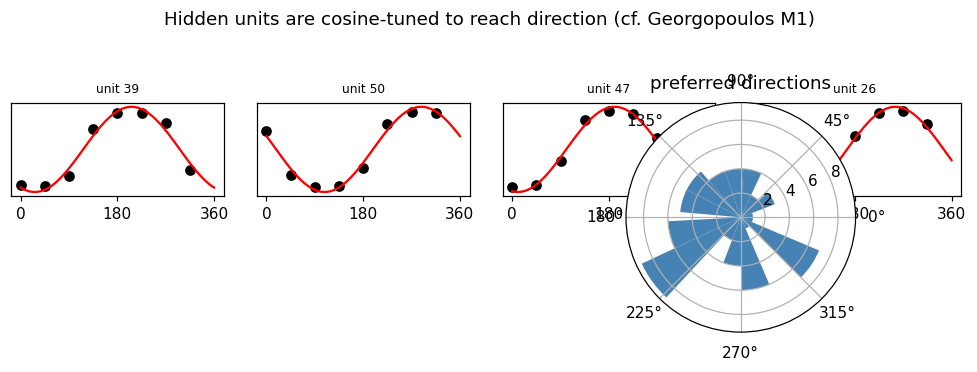

In [8]:
# example tuning curves + distribution of preferred directions
order = np.argsort(-depths)[:4]
th = np.linspace(0, 2*np.pi, 100)
fig = plt.figure(figsize=(9, 3.4))
for k, i in enumerate(order):
    ax = fig.add_subplot(2, 4, k+1)
    ax.plot(np.degrees(ANGLES), H[:, i], "ko")
    beta, *_ = np.linalg.lstsq(Xd, H[:, i], rcond=None)
    ax.plot(np.degrees(th), beta[0]+beta[1]*np.cos(th)+beta[2]*np.sin(th), "r-")
    ax.set_title(f"unit {i}", fontsize=8); ax.set_xticks([0, 180, 360]); ax.set_yticks([])
axp = fig.add_subplot(1, 2, 2, projection="polar")
axp.hist(PDs[tuned], bins=16, color="steelblue")
axp.set_title("preferred directions", va="bottom")
fig.suptitle("Hidden units are cosine-tuned to reach direction (cf. Georgopoulos M1)")
plt.tight_layout(); plt.show()


## The Georgopoulos population vector

Each tuned unit "votes" with a vector along its preferred direction, weighted by its activity.
The **sum** — the population vector — points in the actual reach direction. This is the classic
M1 population-coding result, here decoded from a *learned* RL agent.


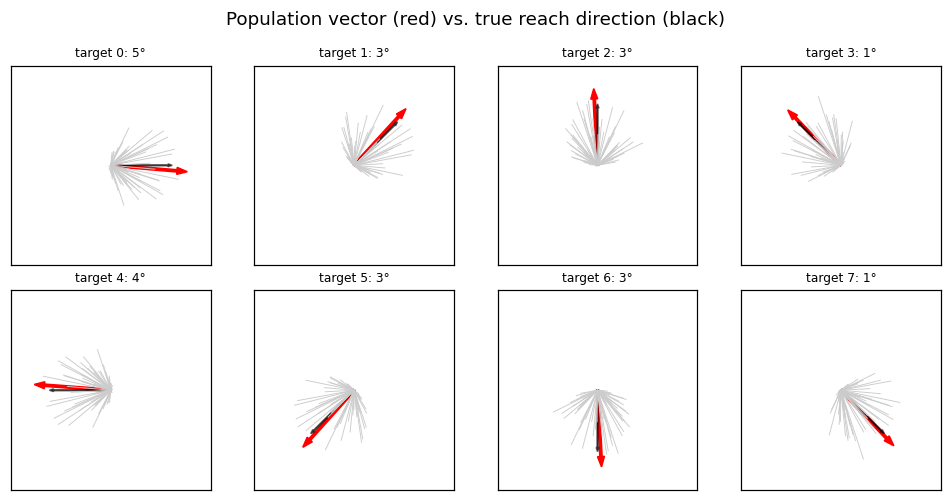

mean population-vector angular error: 2.9 degrees


In [9]:
PD_vec = np.stack([np.cos(PDs), np.sin(PDs)], 1)
fig, ax = plt.subplots(2, 4, figsize=(9, 4.6), subplot_kw=dict(aspect="equal"))
errs = []
for tid in range(N_TARGETS):
    a = ax.flat[tid]
    w = (H[tid] - H[tid].mean())[tuned]
    contribs = w[:, None] * PD_vec[tuned]
    pv = contribs.sum(0)
    for c in contribs:
        a.plot([0, c[0]], [0, c[1]], color="0.8", lw=0.6)
    pv_u = pv / (np.linalg.norm(pv)+1e-9)
    a.arrow(0, 0, pv_u[0], pv_u[1], color="r", width=0.03, length_includes_head=True)
    a.arrow(0, 0, np.cos(ANGLES[tid])*0.8, np.sin(ANGLES[tid])*0.8,
            color="k", width=0.012, length_includes_head=True, alpha=0.6)
    ang = np.arctan2(pv[1], pv[0])
    err = np.degrees(abs(np.angle(np.exp(1j*(ang - ANGLES[tid]))))); errs.append(err)
    a.set_title(f"target {tid}: {err:.0f}°", fontsize=8)
    a.set_xlim(-1.3, 1.3); a.set_ylim(-1.3, 1.3); a.set_xticks([]); a.set_yticks([])
fig.suptitle("Population vector (red) vs. true reach direction (black)")
plt.tight_layout(); plt.show()
print("mean population-vector angular error:", round(np.mean(errs), 1), "degrees")


## Takeaways & the bridge to neural data

- **One scalar, two learners.** The TD error $\delta$ trains both the critic (value) and the
  actor (policy) — the reinforcement-learning incarnation of the **three-factor rule**, with
  $\delta$ playing the role of **dopamine reward-prediction error**.
- **Learned representations look like M1.** To solve directional reaching, the network's units
  become **cosine-tuned** to reach direction, and a **population vector** decodes movement —
  the hallmark of Georgopoulos' motor-cortex population code.
- **➡ Link to the *Neural Data Analysis* tutorial (Session 2, monkey M1 / MC_Maze):** there you
  run *the same* tuning-curve fits, PCA, and population-level analyses on **real motor-cortex
  recordings**. This demo shows those signatures arising naturally in an agent that *learned*
  to reach — connecting synaptic-level learning rules to systems-level neural data.

*The spine, complete:* **2-factor (Hebb/Oja) → objective (infomax/EGHR) → 3-factor (TD / RPE).**
